In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# Initial parameters
S0 = 100      # Current stock price
r = 0.05      # Interest rate
sigma = 0.2   # Volatility
T = 1         # Time (1 year)
simulations = 1000
steps = 100   # Time steps for path simulation

In [27]:
# Generate random values
Z = np.random.standard_normal(simulations)

# Simulate future prices
ST = S0 * np.exp((r - 0.5 * sigma**2)*T + sigma*np.sqrt(T)*Z)

In [28]:

# Simulate multiple price paths
paths = []

for i in range(10):  # 10 sample paths
    prices = [S0]
    for t in range(steps):
        Z = np.random.standard_normal()
        next_price = prices[-1] * np.exp((r - 0.5 * sigma**2)/steps + sigma*np.sqrt(1/steps)*Z)
        prices.append(next_price)
    paths.append(prices)

In [20]:
# Expected price
mean_price = np.mean(ST)

# Risk (volatility)
risk = np.std(ST)

# Value at Risk (VaR)
VaR = np.percentile(ST, 5)

print("📊 Expected Price:", mean_price)
print("📉 Risk (Std Dev):", risk)
print("⚠️ Value at Risk (5%):", VaR)

📊 Expected Price: 105.19057058337877
📉 Risk (Std Dev): 20.38868366328726
⚠️ Value at Risk (5%): 75.65631749711893


In [24]:
K = 100  # Strike price

payoffs = np.maximum(ST - K, 0)
option_price = np.exp(-r*T) * np.mean(payoffs)

print("💰 Call Option Price:", option_price)

💰 Call Option Price: 10.549480714310835


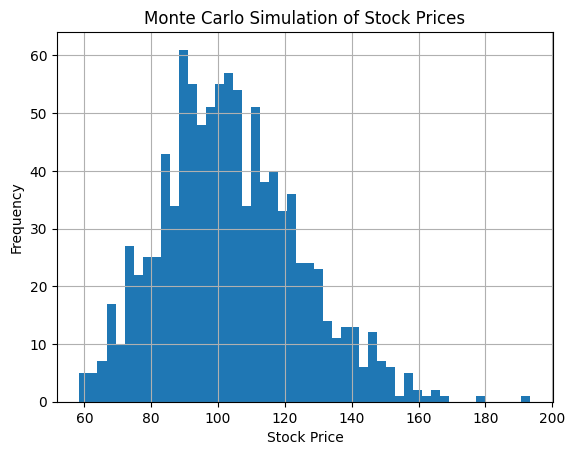

In [29]:

plt.hist(ST, bins=50)
plt.title("Monte Carlo Simulation of Stock Prices")
plt.xlabel("Stock Price")
plt.ylabel("Frequency")
plt.grid()
plt.show()

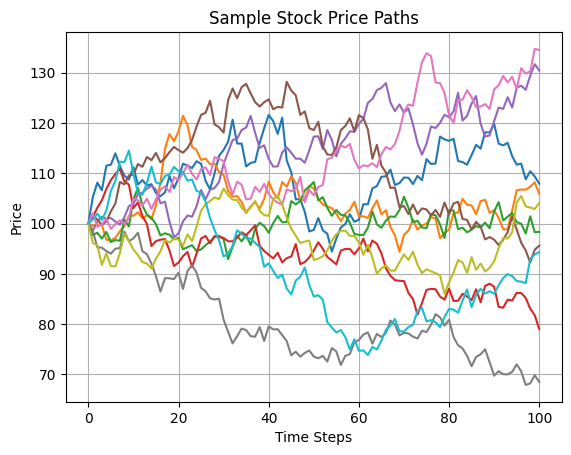

In [30]:
for path in paths:
    plt.plot(path)

plt.title("Sample Stock Price Paths")
plt.xlabel("Time Steps")
plt.ylabel("Price")
plt.grid()
plt.show()